In [ ]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Use the actual notebook working directory
nb_dir = Path.cwd()
print(f"Current notebook path: {nb_dir}")

# Optionally add the notebook dir (for local-only imports)
if str(nb_dir) not in sys.path:
    sys.path.insert(0, str(nb_dir))
    print(f"Added {nb_dir} to sys.path")

# Critically: add the repository root so top-level packages like 'utils' are importable
# Notebook path: /home/luky/skola/KalmanNet-main/navigation NCLT dataset/linear_velocity_integration
# Repo root is two levels up: /home/luky/skola/KalmanNet-main
repo_root = nb_dir.parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    print(f"Added {repo_root} to sys.path")

In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [3]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

# === 1. KONFIGURACE ===
# Cesta k adresáři, který vytvořil preprocess skript
data_dir = '../preprocessed_NCLT_trajectory-2012-01-22-angle-update'

print(f"Načítám data z: {data_dir}...")

train_data = torch.load(os.path.join(data_dir, 'train.pt'))
val_data = torch.load(os.path.join(data_dir, 'val.pt'))
test_data = torch.load(os.path.join(data_dir, 'test.pt'))

# Extrakce tensorů (předpokládáme 1 trajektorii v listu)
X_train, Y_train = train_data[0]['ground_truth'], train_data[0]['filtered_gps']
X_val, Y_val     = val_data[0]['ground_truth'],   val_data[0]['filtered_gps']
X_test, Y_test   = test_data[0]['ground_truth'],  test_data[0]['filtered_gps']

# Spojení zpět do jedné sekvence pro vizualizaci celé trajektorie
X_full = torch.cat([X_train, X_val, X_test], dim=0)
Y_full = torch.cat([Y_train, Y_val, Y_test], dim=0)


Načítám data z: ../preprocessed_NCLT_trajectory-2012-01-22-angle-update...


# Model definition

In [4]:
import torch
import math
import Systems 

# Nastavení zařízení
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#########################
### Design Parameters ###
### (OPTIMALIZOVANÉ)  ###
#########################

# 1. Rozměry
# Stav: [px, vx, py, vy]
m = 4 
n = 4 
delta_t = 1.0 

# 2. Dynamika (F)
# x_{t+1} = x_t + v_t * dt
F_dim = torch.tensor([[1.0, delta_t],
                      [0.0, 1.0]])

F_design = torch.block_diag(F_dim, F_dim).float()

# 3. Měření (H)
H_design = torch.eye(n).float()

# ==========================================
# 4. Šum procesu (Q) - OPTIMALIZOVÁNO
# ==========================================
# Hodnota z Optuny (MSE ~760)
# q_scale = 0.00006806
# q_scale = 0.00013203

# grid search:
q_scale = 0.00012224

# Používáme kinematický model (Discrete White Noise Acceleration), 
# který byl použit v optimalizačním skriptu.
# Blok pro jednu dimenzi (pozice + rychlost):
Q_block_val = torch.tensor([
    [(delta_t**3)/3, (delta_t**2)/2],
    [(delta_t**2)/2,  delta_t      ]
]) * q_scale

# Výsledná Q pro [px, vx, py, vy]
Q_design = torch.block_diag(Q_block_val, Q_block_val).float()


# ==========================================
# 5. Šum měření (R) - OPTIMALIZOVÁNO
# ==========================================
# Hodnoty z Optuny
# var_gps = 38.370833  # Vysoká nedůvěra v GPS (odpovídá realitě NCLT)
# var_odo = 0.000560   # Extrémní důvěra v Odometrii
# var_gps = 39.321669
# var_odo = 0.00057
#grid search:
var_gps = 39.275433
var_odo = 0.000566


# Pořadí stavů: [Pos_X, Vel_X, Pos_Y, Vel_Y]
# Takže střídáme: [GPS, ODO, GPS, ODO]
R_design = torch.tensor([
    [var_gps, 0.0,     0.0,     0.0],
    [0.0,     var_odo, 0.0,     0.0],
    [0.0,     0.0,     var_gps, 0.0],
    [0.0,     0.0,     0.0,     var_odo]
]).float()

# 6. Počáteční podmínky
m1x_0 = torch.zeros(m, 1).float()
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0])) # Velká nejistota v pozici, menší v rychlosti

print("\nInicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...")
print(f"Dimenze stavu: {m}, Dimenze měření: {n}")
print(f"Q scale: {q_scale}")
print(f"R diagonal: {torch.diagonal(R_design)}")

# === INICIALIZACE SYSTÉMŮ ===

sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

print("... Systémy inicializovány.")
print("POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].")


Inicializuji systém dle OPTIMALIZOVANÝCH parametrů (NCLT)...
Dimenze stavu: 4, Dimenze měření: 4
Q scale: 0.00012224
R diagonal: tensor([3.9275e+01, 5.6600e-04, 3.9275e+01, 5.6600e-04])
... Systémy inicializovány.
POZOR: Tento model očekává pořadí stavů [px, vx, py, vy].


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# === 1. KONFIGURACE ===
# Dynamicky zjistíme délku testovací sady z proměnné X_test (kterou máme z minula)
# Pokud by X_test neexistovalo, kód spadne, ale to by znamenalo, že jsi nenačetl data.
TEST_SEQ_LEN = X_test.shape[0] 

TRAIN_SEQ_LEN = 50    # Délka sekvence pro trénink (krátká okna)
VAL_SEQ_LEN = 200     # Validace po delších úsecích
STRIDE = 10           # Posun okna (překryv)
BATCH_SIZE = 128      # Velikost dávky

def create_sequences(X, Y, seq_len, stride=1):
    """
    Rozseká dlouhé tenzory [Total_Len, Dim] na sekvence [N_seq, Seq_Len, Dim].
    """
    xs = []
    ys = []
    num_samples = X.shape[0]
    
    # Pokud je seq_len větší než data (např. u testu), vezmeme prostě to, co máme
    if seq_len > num_samples:
        seq_len = num_samples
    
    for i in range(0, num_samples - seq_len + 1, stride):
        x_seq = X[i : i+seq_len, :]
        y_seq = Y[i : i+seq_len, :]
        xs.append(x_seq)
        ys.append(y_seq)
        
    if len(xs) == 0:
        # Fallback: Pokud by data byla kratší než seq_len, vrátíme prázdné nebo 1 kus
        return X.unsqueeze(0), Y.unsqueeze(0)
        
    return torch.stack(xs), torch.stack(ys)

def clean_sequences(X_seq, Y_seq, name="Dataset"):
    """
    Filtruje sekvence, které obsahují jakékoliv NaN nebo Inf hodnoty.
    """
    if X_seq.numel() == 0:
        print(f"⚠️ {name}: Prázdný vstup!")
        return X_seq, Y_seq

    # Zkontrolujeme NaN/Inf pro každou sekvenci zvlášť
    is_nan_x = torch.isnan(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    is_inf_x = torch.isinf(X_seq).reshape(X_seq.shape[0], -1).any(dim=1)
    
    is_nan_y = torch.isnan(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    is_inf_y = torch.isinf(Y_seq).reshape(Y_seq.shape[0], -1).any(dim=1)
    
    invalid_mask = is_nan_x | is_inf_x | is_nan_y | is_inf_y
    valid_mask = ~invalid_mask
    
    X_clean = X_seq[valid_mask]
    Y_clean = Y_seq[valid_mask]
    
    n_dropped = invalid_mask.sum().item()
    if n_dropped > 0:
        print(f"⚠️ {name}: Odstraněno {n_dropped} vadných sekvencí (NaN/Inf). Zbývá: {len(X_clean)}")
    else:
        print(f"✅ {name}: Data jsou čistá. ({len(X_clean)} sekvencí)")
        
    return X_clean, Y_clean

print("--- ZPRACOVÁNÍ DAT ---")

# === 2. TVORBA SEKVENCÍ A PŘETYPOVÁNÍ ===
# OPRAVA PROMĚNNÝCH: Používáme X_train, Y_train atd. místo train_target/input
# X = Ground Truth, Y = Měření (Input)
print(f"Generuji sekvence (Test délka: {TEST_SEQ_LEN})...")

# Train: Krátká okna s překryvem
train_X_raw, train_Y_raw = create_sequences(X_train.float(), Y_train.float(), TRAIN_SEQ_LEN, STRIDE)

# Val: Delší okna (bez překryvu)
val_X_raw, val_Y_raw = create_sequences(X_val.float(), Y_val.float(), VAL_SEQ_LEN, VAL_SEQ_LEN)

# Test: Jedna dlouhá sekvence (pro kontinuální vyhodnocení)
# Stride = TEST_SEQ_LEN zajistí, že dostaneme právě jeden (nebo málo) dlouhých kusů
test_X_raw, test_Y_raw = create_sequences(X_test.float(), Y_test.float(), TEST_SEQ_LEN, TEST_SEQ_LEN)

# === 3. ČIŠTĚNÍ DAT (NAN/INF FILTER) ===
print("\nFiltruji NaN hodnoty...")
train_X_seq, train_Y_seq = clean_sequences(train_X_raw, train_Y_raw, "Train")
val_X_seq, val_Y_seq = clean_sequences(val_X_raw, val_Y_raw, "Val")
test_X_seq, test_Y_seq = clean_sequences(test_X_raw, test_Y_raw, "Test")

# === 4. VYTVOŘENÍ DATALOADERŮ ===
print("\nVytvářím DataLoadery...")
# Train: Shuffle=True (Důležité pro trénink)
train_dataset = TensorDataset(train_X_seq, train_Y_seq)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Val/Test: Shuffle=False (Abychom viděli průběh)
val_dataset = TensorDataset(val_X_seq, val_Y_seq)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(test_X_seq, test_Y_seq)
# Pro test batch_size=1, protože máme jednu obří sekvenci (nebo pár velkých)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"\n✅ HOTOVO. Připraveno k tréninku.")
print(f"Train batches: {len(train_loader)} (Batch shape: {next(iter(train_loader))[0].shape})")
print(f"Test batches:  {len(test_loader)} (Seq len: {test_X_seq.shape[1]})")

--- ZPRACOVÁNÍ DAT ---
Generuji sekvence (Test délka: 522)...

Filtruji NaN hodnoty...
✅ Train: Data jsou čistá. (360 sekvencí)
✅ Val: Data jsou čistá. (5 sekvencí)
✅ Test: Data jsou čistá. (1 sekvencí)

Vytvářím DataLoadery...

✅ HOTOVO. Připraveno k tréninku.
Train batches: 3 (Batch shape: torch.Size([128, 50, 4]))
Test batches:  1 (Seq len: 522)


In [6]:
import torch
import numpy as np
from MDM.MDM_functions import MDM_nullO_LTI, pinv, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

from tqdm import tqdm

class KalmanFilter:
    """
    Kalmanův filtr pro t-invaritantní systém s lineární dynamikou.
    (Původní implementace beze změn)
    """
    def __init__(self,model):
        self.device = model.Q.device
        self.model = model
        self.Ex0 = model.Ex0
        self.P0 = model.P0
        self.F = model.F
        self.H = model.H
        self.Q = model.Q
        self.R = model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]

        # Interní stav pro online použití
        self.x_predict_current = None
        self.P_predict_current = None
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def predict_step(self, x_filtered, P_filtered):
        x_predict = self.F @ x_filtered
        P_predict = self.F @ P_filtered @ self.F.T + self.Q
        return x_predict, P_predict

    def update_step(self, x_predict, y_t, P_predict):
        y_t = y_t.reshape(self.obs_dim, 1)
        innovation = self.compute_innovation(y_t, x_predict)
        K = self.compute_kalman_gain(P_predict)
        x_filtered = x_predict + K @ innovation
        I = torch.eye(self.state_dim, device=self.device)
        P_filtered = (I - K @ self.H) @ P_predict @ (I - K @ self.H).T + K @ self.R @ K.T 
        return x_filtered, P_filtered, K, innovation

    def compute_kalman_gain(self, P_predict):
        return P_predict @ self.H.T @ torch.linalg.inv(self.H @ P_predict @ self.H.T + self.R)
    
    def compute_innovation(self, y_t, x_predict):
        return y_t - self.H @ x_predict
    
    def step(self, y_t):
        x_filtered, P_filtered, _, _ = self.update_step(self.x_predict_current, y_t, self.P_predict_current)
        x_predict_next, P_predict_next = self.predict_step(x_filtered, P_filtered)
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next
        return x_filtered, P_filtered

    def process_sequence(self, y_seq, Ex0=None, P0=None):
            seq_len = y_seq.shape[0]
            x_filtered_history = torch.zeros(seq_len, self.state_dim, device=self.device)
            P_filtered_history = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device)
            kalman_gain_history = torch.zeros(seq_len, self.state_dim, self.obs_dim, device=self.device)
            innovation_history = torch.zeros(seq_len, self.obs_dim, device=self.device)

            if Ex0 is None: Ex0 = self.Ex0
            if P0 is None: P0 = self.P0
            x_predict_k = Ex0.clone().detach().reshape(self.state_dim, 1)
            P_predict_k = P0.clone().detach()
            
            for k in range(seq_len):
                x_filtered, P_filtered, K, innovation = self.update_step(x_predict_k, y_seq[k], P_predict_k)
                x_predict_k_plus_1, P_predict_k_plus_1 = self.predict_step(x_filtered, P_filtered)
                x_predict_k = x_predict_k_plus_1
                P_predict_k = P_predict_k_plus_1
                x_filtered_history[k] = x_filtered.squeeze()
                P_filtered_history[k] = P_filtered
                kalman_gain_history[k] = K
                innovation_history[k] = innovation.squeeze()

            return {
                'x_filtered': x_filtered_history,
                'P_filtered': P_filtered_history,
                'Kalman_gain': kalman_gain_history,
                'innovation': innovation_history
            }

class AdaptiveKalmanFilter_online:
    def __init__(self, model, mdm_L=4, mdm_version=1, lambda_rls=0.995, q_init=1e-3, init_sigma_rls_value=10.0, alpha_nom=None):
        """
        Adaptivní KF (Semi-weighted Recursive verze - Sw-Re).
        Tato třída provádí online identifikaci matic Q a R.
        """
        self.kf = KalmanFilter(model)
        self.device = model.Q.device
        
        self.mdm_L = mdm_L
        self.mdm_version = mdm_version
        self.lambda_rls = lambda_rls
        self.q_init_val = q_init
        self.init_sigma_val = init_sigma_rls_value
        self.alpha_nom_val = alpha_nom
        self.nw = self.kf.F.shape[0] # Dimenze stavového šumu (W)
        self.nv = self.kf.H.shape[0] # Dimenze šumu měření (V)
        
        self.T = T = 1.0
        T2 = (T**2) / 2.0
        T3 = (T**3) / 3.0
        
        self.Q_template = np.array([
            [T3, T2, 0,  0],
            [T2, T,  0,  0],
            [0,  0,  T3, T2],
            [0,  0,  T2, T]
        ])
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full = (self.nw * (self.nw + 1)) // 2 
        self.n_params_R_full = (self.nv * (self.nv + 1)) // 2
        self.n_params_R_reduced = 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced))
        self.T_R_matrix[0, 0] = 1.0 
        self.T_R_matrix[7, 0] = 1.0 
        self.T_R_matrix[4, 1] = 1.0 
        self.T_R_matrix[9, 1] = 1.0 
        
        # 3. INICIALIZACE RLS
        self.n_params = 1 + self.n_params_R_reduced

        self.q_init = self.q_init_val
        
        R0 = model.R.cpu().numpy()
        r1_init = R0[0,0]
        r2_init = R0[1,1]
        
        self.alpha_est = np.array([self.q_init, r1_init, r2_init], dtype=np.float64)
        
        # BEZPEČNÉ NAČTENÍ alpha_nom (Zůstáváme u 1D pole)
        if self.alpha_nom_val is not None:
            self.alpha_nom = np.array(self.alpha_nom_val, dtype=np.float64)
        else:
            self.alpha_nom = np.copy(self.alpha_est)

        # P_RLS
        sigma_q  = (self.alpha_nom[0] * self.init_sigma_val)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * self.init_sigma_val)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * self.init_sigma_val)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2])
        # Buffery
        self.z_buffer = []
        self.u_buffer = []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        """
        Pomocná funkce pro získání matice Upsilon.
        Tato matice je čistě strukturální (záleží jen na dimenzích) a slouží
        k manipulaci s Kroneckerovými součiny v rámci MDM teorie.
        Počítá se jen jednou.
        """
        if self.Upsilon_2 is None:
            w2b = [baseMatrix_fun(self.nw, 1)] 
            v2b = [baseMatrix_fun(self.nv, 1)] 
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def _reconstruct_qr_from_alpha2(self, alpha_2):
        """
        KLÍČOVÁ FUNKCE: Převod vektoru parametrů zpět na matice.
        
        Vstup: alpha_2 (vektor délky n_params)
        Výstup: Matice Q a R
        
        Logika:
        1. Rozdělí vektor alpha na část pro Q a část pro R.
        2. Vytvoří prázdné matice.
        3. Vyplní horní trojúhelník (triu) hodnotami z vektoru.
        4. Zkopíruje hodnoty i do dolního trojúhelníku (symetrizace),
           protože kovarianční matice musí být symetrická (Q_ij = Q_ji).
        """
        # Kolik prvků patří matici Q?
        q_len = (self.nw * (self.nw + 1)) // 2
        
        # Rozdělení vektoru
        alpha_q = alpha_2[:q_len]
        alpha_r = alpha_2[q_len:]
        
        # Rekonstrukce Q
        Q_est = np.zeros((self.nw, self.nw))
        i, j = np.triu_indices(self.nw)
        # Vyplnění horního trojúhelníku
        Q_est[i, j] = alpha_q
        # Symetrizace: Q[j, i] = Q[i, j]
        # Tímto říkáme, že kovariance mezi stavem 1 a 2 je stejná jako mezi 2 a 1.
        Q_est[j, i] = alpha_q
        
        # Rekonstrukce R (stejný princip)
        R_est = np.zeros((self.nv, self.nv))
        i, j = np.triu_indices(self.nv)
        R_est[i, j] = alpha_r
        R_est[j, i] = alpha_r
        
        return Q_est, R_est

    def step_adaptive(self, y_t, u_t=None):
        """
        Jeden krok adaptivního filtru s UNWEIGHTED RLS.
        """
        # --- 1. Update Bufferu (Posuvné okno) ---
        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        
        if u_t is not None:
            u_np = u_t.cpu().numpy().squeeze()
            if u_np.ndim == 0: u_np = np.expand_dims(u_np, axis=0)
        else:
            u_np = np.zeros(1)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        # Udržování fixní délky okna L (FIFO fronta)
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        # --- 2. Identifikace Q a R (RLS) ---
        # Spustí se pouze, pokud je buffer plný (dost dat pro MDM)
        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer)
                u_window = np.array(self.u_buffer)
                
                # Získání matic systému
                F_np = self.kf.F.cpu().numpy()
                H_np = self.kf.H.cpu().numpy()
                G_np = np.zeros((self.nw, u_window.shape[1])) # matice pro vstup u 
                E_np = np.eye(self.nw) # matice pro šum w
                D_np = np.eye(self.nv) # matice pro šum v
                nz_np = np.array([self.nv])

                # MDM: Výpočet rezidua a regresoru
                # r_k: Vektor reziduí, který nese informaci o šumu v datech
                # Awv_matrix: Pomocná matice popisující dynamiku systému v okně
                r_list, Awv_matrix = MDM_nullO_LTI(
                    self.mdm_L, F_np, G_np, E_np, nz_np, H_np, D_np, 
                    z_window, u_window, self.mdm_version
                )
                r_k = r_list[0]
                
                nr = r_k.shape[0]
                Ksi = Ksi_fun(nr) # Unifikační matice (vybírá unikátní prvky ze symetrické matice)
                
                # Pozorování pro RLS (y_rls):
                # Vychází z vnějšího součinu rezidua (r_k * r_k^T), což je "okamžitá kovariance".
                # kron2_vec to převede na vektor a Ksi vybere unikátní prvky.
                # OPRAVA TADY: Zploštění y_rls
                y_rls = (Ksi @ kron2_vec(r_k)).flatten()
                
                # Regresní matice (H_rls):
                # Popisuje lineární vztah mezi parametry (Q, R) a pozorováním (kovariancí rezidua).
                Upsilon = self._get_upsilon()
                H_full = Ksi @ kron2_mat(Awv_matrix) @ Upsilon

                # 1. Rozdělení na Q část a R část
                H_Q_part_full = H_full[:, :self.n_params_Q_full] 
                H_R_part_full = H_full[:, self.n_params_Q_full:]
                
                # 2. Transformace Q (10 sloupců -> 1 sloupec)
                h_q_new = H_Q_part_full @ self.vec_Q_template

                # 3. NOVÉ: Transformace R (10 sloupců -> 2 sloupce)
                # Výsledek má tvar [N, 2]. První sloupec je citlivost na r1, druhý na r2.
                H_R_new = H_R_part_full @ self.T_R_matrix

                # 4. Sestavení finálního H_rls
                H_rls = np.hstack([h_q_new, H_R_new])
                
                # =========================================================
                # VÁŽENÉ RLS PŘES NORMALIZACI DAT (Stabilní a fungující)
                # =========================================================
                
                # 2. Výpočet vah na základě nominálních hodnot (Zploštění)
                y_expected_nom = np.abs(H_rls @ self.alpha_nom).flatten()
                weights = y_expected_nom + 1e-8
                
                # 3. Normalizace rovnic (vydělení vahami)
                y_rls_norm = y_rls / weights
                H_rls_norm = H_rls / weights[:, np.newaxis]
                
                # 4. RLS Update na znormalizovaných datech (Omega je teď Identita)
                dim_obs_rls = H_rls_norm.shape[0]
                Omega_norm = np.eye(dim_obs_rls)

                S = H_rls_norm @ self.Sigma_RLS @ H_rls_norm.T + Omega_norm
                
                # S je nyní skvěle podmíněná, pinv funguje perfektně
                K_gain = self.Sigma_RLS @ H_rls_norm.T @ np.linalg.pinv(S)
                
                error = y_rls_norm - H_rls_norm @ self.alpha_est
                self.alpha_est = self.alpha_est + K_gain @ error
                
                I_p = np.eye(self.n_params)
                self.Sigma_RLS = (I_p - K_gain @ H_rls_norm) @ self.Sigma_RLS / self.lambda_rls
                # =========================================================
                
                # --- REKONSTRUKCE MATIC ---
                
                q_est = self.alpha_est[0]
                # Q nesmí klesnout pod 1e-5, jinak KF přestane naslouchat odometrii!
                q_safe = max(q_est, 1e-5) 
                Q_new = q_safe * self.Q_template
                
                # 2. R_GPS (Ať si klidně letí nahoru, ale nesmí klesnout pod realitu)
                # Dle grafů je minimální slušné R kolem 10-20. 
                r1_est = max(self.alpha_est[1], 10.0) 
                
                # 3. R_ODO (Zabránění nedůvěře k odometrii)
                r2_est = self.alpha_est[2]
                r2_est = max(r2_est, 1e-4) # Spodní hranice (aby se nedělilo nulou)
                # DŮLEŽITÉ: Strop! Dle grafů je nejhorší chyba odo 2 m/s (variance 4). 
                # Nedovolte filtru odhadnout R_ODO vyšší než např. 0.5, jinak odometrii odřízne!
                r2_est = min(r2_est, 0.005) 
                
                R_new = np.diag([r1_est, r2_est, r1_est, r2_est])
                
                # Update KF
                self.kf.Q = torch.from_numpy(Q_new).float().to(self.device)
                self.kf.R = torch.from_numpy(R_new).float().to(self.device)
                
            except Exception as e:
                import traceback
                print(f"Chyba v RLS aktualizaci:")
                traceback.print_exc()
                pass

        # --- 3. Filtrace ---
        # Provedeme standardní krok Kalmanova filtru s aktuálními Q a R
        x_filt, P_filt = self.kf.step(y_t)
        return x_filt, P_filt, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, u_seq=None, Ex0=None, P0=None):
        """
        Pomocná metoda pro simulaci běhu na celé sekvenci dat.
        """
        seq_len = y_seq.shape[0]
        
        # 1. Kompletní reset (zapomeneme vše z předchozích běhů)
        self.__init__(
            self.kf.model, 
            self.mdm_L, 
            self.mdm_version, 
            self.lambda_rls,
            q_init=self.q_init_val,                # <--- Předat dál
            init_sigma_rls_value=self.init_sigma_val,
            alpha_nom=self.alpha_nom_val # <--- TOTO CHYBĚLO: Předat parametr při resetu!
        )

        # 2. Nastavení počátečních podmínek
        if Ex0 is None: Ex0 = self.kf.model.Ex0
        if P0 is None: P0 = self.kf.model.P0

        # 3. Reset vnitřního KF
        self.kf.reset(Ex0, P0)
        
        self.z_buffer = []
        self.u_buffer = []

        x_hist = torch.zeros(seq_len, self.kf.state_dim, device=self.device)
        P_hist = torch.zeros(seq_len, self.kf.state_dim, self.kf.state_dim, device=self.device)
        Q_hist = []
        R_hist = []

        for k in tqdm(range(0,seq_len), desc="Processing sequence adaptively"):
            y_t = y_seq[k]
            u_t = u_seq[k] if u_seq is not None else None
            
            x, P, Q_curr, R_curr = self.step_adaptive(y_t, u_t)
            
            x_hist[k] = x.squeeze()
            P_hist[k] = P
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        results_dict = {
            'x_filtered': x_hist,
            'P_filtered': P_hist
        }
        
        return results_dict, Q_hist, R_hist

In [7]:
import torch
import numpy as np
from tqdm import tqdm

class AdaptiveKalmanFilter_mehra:
    def __init__(self, model, window_size=200):
        self.model = model
        self.dtype = model.F.dtype
        self.device = model.Q.device
        
        self.nx = self.model.F.shape[0]
        self.nz = self.model.H.shape[0]
        
        # Nastavení velikosti klouzavého okna
        self.window_size = window_size
        self.inov_buffer = []
        
        self.reset()

    def reset(self, Ex0=None, P0=None):
        """Vymaže buffery a zresetuje vnitřní stav před novou trajektorií."""
        if Ex0 is None: Ex0 = self.model.Ex0
        if P0 is None: P0 = self.model.P0
            
        self.x_predict = Ex0.clone().detach().reshape(self.nx, 1)
        self.inov_buffer = []
        
        # 1. Zvolme stabilní K lineárního filtru
        self.K = 0.1 * torch.linalg.pinv(self.model.H)
    
    def step(self, y_t):
        y_t = y_t.reshape(self.nz, 1)
        
        inov = y_t - self.model.H @ self.x_predict
        
        # Přidání nové inovace do okna
        self.inov_buffer.append(inov)
            
        # --- ZMĚNA 1: Princip klouzavého okna ---
        # Pokud okno přeteče, odstraníme nejstarší záznam zleva
        if len(self.inov_buffer) > self.window_size:
            self.inov_buffer.pop(0)
            
        N_current = len(self.inov_buffer)
        
        # --- ZMĚNA 2: Podmínka běhu ---
        # Výpočet matic proběhne v každém kroku, jakmile je okno plně naplněno
        if N_current == self.window_size:
            inov_tensor = torch.cat(self.inov_buffer, dim=1)
            
            # Odhad kovariancí pro l=0
            Py0 = (inov_tensor @ inov_tensor.T) / N_current
            
            Py_list = [Py0] 
            
            # Spočítáme \hat{P}_l^y podle rovnice (22)
            for l in range(1, self.nx + 10):
                inov_shift = inov_tensor[:, l:]
                inov_orig = inov_tensor[:, :-l]
                Py_l = (inov_shift @ inov_orig.T) / (N_current - l)
                Py_list.append(Py_l)
                
            G_list = []
            V_list = [] 
            
            F = self.model.F
            H = self.model.H
            K = self.K
            
            # Sestavení G podle rovnice (21) a matici V podle (23)
            for l in range(1, self.nx + 10):
                # Matice G: G_l = H * F^l
                G_l = H @ torch.matrix_power(F, l)
                G_list.append(G_l)
                
                # Matice V (Rovnice 23): Každý řádek je součet
                V_l = Py_list[l].clone()
                for i in range(1, l + 1):
                    term = H @ torch.matrix_power(F, i) @ K @ Py_list[l - i]
                    V_l += term
                V_list.append(V_l)
                
            G = torch.cat(G_list, dim=0)
            V = torch.cat(V_list, dim=0)
            
            # Odhad součinu P^e * H^T podle rovnice (23)
            PHT = torch.linalg.pinv(G) @ V
            
            # Odhad Kalmanova zisku
            Py0_inv = torch.linalg.pinv(Py0 + 1e-6 * torch.eye(self.nz, device=self.device,dtype=self.dtype))
            K_est = PHT @ Py0_inv
            
            if not (torch.isnan(K_est).any() or torch.isinf(K_est).any()):
                A_test = F - F @ K_est @ H
                eigvals = torch.linalg.eigvals(A_test)
                max_eig = torch.max(torch.abs(eigvals))
                
                if max_eig < 1.0:
                    # Zisk je stabilní, takže ho aktualizujeme
                    self.K = K_est
                else:
                    # Statistická odchylka v tomto bloku způsobila nestabilitu.
                    # Zisk nezměníme a jedeme dál s předchozím stabilním K.
                    pass
            
            # --- ZMĚNA 3: Smazán řádek `self.inov_buffer = []` ---
            # Díky tomu okno zůstává naplněné a v dalším kroku se jen posune.
            
        # Filtrace a predikce na další krok
        x_filtered = self.x_predict + self.K @ inov
        self.x_predict = self.model.F @ x_filtered
        
        return x_filtered, self.K

    def process_sequence(self, y_seq, Ex0=None, P0=None):
        seq_len = y_seq.shape[0]
        
        self.reset(Ex0, P0)
        
        x_filtered_history = torch.zeros(seq_len, self.nx, device=self.device,dtype=self.dtype)
        P_filtered_history = torch.zeros(seq_len, self.nx, self.nx, device=self.device,dtype=self.dtype)
        kalman_gain_history = torch.zeros(seq_len, self.nx, self.nz, device=self.device,dtype=self.dtype)
        innovation_history = torch.zeros(seq_len, self.nz, device=self.device,dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Online filtrace s adaptivním K", leave=False):
            z_t = y_seq[k].reshape(self.nz, 1)
            inov_k = z_t - self.model.H @ self.x_predict
            
            x_filtered, K_current = self.step(y_seq[k])
            
            x_filtered_history[k] = x_filtered.squeeze()
            kalman_gain_history[k] = K_current
            innovation_history[k] = inov_k.squeeze()
            
        return {
            'x_filtered': x_filtered_history,
            'P_filtered': P_filtered_history,
            'Kalman_gain': kalman_gain_history,
            'innovation': innovation_history
        }

In [8]:
import torch
import numpy as np
from tqdm import tqdm

class AdaptiveKalmanFilter_mehra:
    def __init__(self, model, window_size=200):
        self.model = model
        self.dtype = model.F.dtype
        self.device = model.Q.device
        
        self.nx = self.model.F.shape[0]
        self.nz = self.model.H.shape[0]
        
        # Nastavení velikosti blokového okna
        self.window_size = window_size
        self.inov_buffer = []
        
        self.reset()

    def reset(self, Ex0=None, P0=None):
        """Vymaže buffery a zresetuje vnitřní stav před novou trajektorií."""
        if Ex0 is None: Ex0 = self.model.Ex0
        if P0 is None: P0 = self.model.P0
            
        self.x_predict = Ex0.clone().detach().reshape(self.nx, 1)
        self.inov_buffer = []
        
        # 1. Zvolme stabilní K lineárního filtru
        self.K = 0.1 * torch.linalg.pinv(self.model.H)
    
    def step(self, y_t):
        y_t = y_t.reshape(self.nz, 1)
        
        inov = y_t - self.model.H @ self.x_predict
        
        # Přidání nové inovace do okna
        self.inov_buffer.append(inov)
            
        N_current = len(self.inov_buffer)
        
        # Výpočet matic proběhne až po úplném naplnění bloku
        if N_current >= self.window_size:
            inov_tensor = torch.cat(self.inov_buffer, dim=1)
            
            # Odhad kovariancí pro l=0
            Py0 = (inov_tensor @ inov_tensor.T) / N_current
            
            Py_list = [Py0] 
            
            # Spočítáme \hat{P}_l^y podle rovnice (22)
            for l in range(1, self.nx + 5):
                inov_shift = inov_tensor[:, l:]
                inov_orig = inov_tensor[:, :-l]
                Py_l = (inov_shift @ inov_orig.T) / (N_current - l)
                Py_list.append(Py_l)
                
            G_list = []
            V_list = [] 
            
            F = self.model.F
            H = self.model.H
            K = self.K
            
            # Sestavení G podle rovnice (21) a matici V podle (23)
            for l in range(1, self.nx + 5):
                # Matice G: G_l = H * F^l
                G_l = H @ torch.matrix_power(F, l)
                G_list.append(G_l)
                
                # Matice V (Rovnice 23): Každý řádek je součet
                V_l = Py_list[l].clone()
                for i in range(1, l + 1):
                    term = H @ torch.matrix_power(F, i) @ K @ Py_list[l - i]
                    V_l += term
                V_list.append(V_l)
                
            G = torch.cat(G_list, dim=0)
            V = torch.cat(V_list, dim=0)
            
            # Odhad součinu P^e * H^T podle rovnice (23)
            PHT = torch.linalg.pinv(G) @ V
            
            # Odhad Kalmanova zisku
            Py0_inv = torch.linalg.pinv(Py0 + 1e-6 * torch.eye(self.nz, device=self.device,dtype=self.dtype))
            K_est = PHT @ Py0_inv
            
            if not (torch.isnan(K_est).any() or torch.isinf(K_est).any()):
                A_test = F - F @ K_est @ H
                eigvals = torch.linalg.eigvals(A_test)
                max_eig = torch.max(torch.abs(eigvals))
                
                if max_eig < 1.0:
                    self.K = K_est
                else:
                    # Statistická odchylka v tomto bloku způsobila nestabilitu.
                    # Zisk nezměníme a jedeme dál s předchozím stabilním K.
                    pass
            
            # --- ZMĚNA ZPĚT: Vyprázdnění bufferu pro čistě blokový přístup ---
            self.inov_buffer = []
            
        # Filtrace a predikce na další krok
        x_filtered = self.x_predict + self.K @ inov
        self.x_predict = self.model.F @ x_filtered
        
        return x_filtered, self.K

    def process_sequence(self, y_seq, Ex0=None, P0=None):
        seq_len = y_seq.shape[0]
        
        self.reset(Ex0, P0)
        
        x_filtered_history = torch.zeros(seq_len, self.nx, device=self.device,dtype=self.dtype)
        P_filtered_history = torch.zeros(seq_len, self.nx, self.nx, device=self.device,dtype=self.dtype)
        kalman_gain_history = torch.zeros(seq_len, self.nx, self.nz, device=self.device,dtype=self.dtype)
        innovation_history = torch.zeros(seq_len, self.nz, device=self.device,dtype=self.dtype)
        
        for k in tqdm(range(seq_len), desc="Online filtrace s adaptivním K", leave=False):
            z_t = y_seq[k].reshape(self.nz, 1)
            inov_k = z_t - self.model.H @ self.x_predict
            
            x_filtered, K_current = self.step(y_seq[k])
            
            x_filtered_history[k] = x_filtered.squeeze()
            kalman_gain_history[k] = K_current
            innovation_history[k] = inov_k.squeeze()
            
        return {
            'x_filtered': x_filtered_history,
            'P_filtered': P_filtered_history,
            'Kalman_gain': kalman_gain_history,
            'innovation': innovation_history
        }

In [9]:
import torch
import numpy as np
from MDM.MDM_functions import MDM_nullO_LTI, pinv, Ksi_fun, baseMatrix_fun, Upsilon_2_fun, kron2_vec, kron2_mat

from tqdm import tqdm

class KalmanFilter:
    """
    Kalmanův filtr pro t-invaritantní systém s lineární dynamikou.
    (Původní implementace beze změn)
    """
    def __init__(self,model):
        self.device = model.Q.device
        self.model = model
        self.Ex0 = model.Ex0
        self.P0 = model.P0
        self.F = model.F
        self.H = model.H
        self.Q = model.Q
        self.R = model.R
        self.state_dim = self.F.shape[0]
        self.obs_dim = self.H.shape[0]

        # Interní stav pro online použití
        self.x_predict_current = None
        self.P_predict_current = None
        self.reset(model.Ex0, model.P0)

    def reset(self, Ex0, P0):
        self.x_predict_current = Ex0.clone().detach().reshape(self.state_dim, 1)
        self.P_predict_current = P0.clone().detach()

    def predict_step(self, x_filtered, P_filtered):
        x_predict = self.F @ x_filtered
        P_predict = self.F @ P_filtered @ self.F.T + self.Q
        return x_predict, P_predict

    def update_step(self, x_predict, y_t, P_predict):
        y_t = y_t.reshape(self.obs_dim, 1)
        innovation = self.compute_innovation(y_t, x_predict)
        K = self.compute_kalman_gain(P_predict)
        x_filtered = x_predict + K @ innovation
        I = torch.eye(self.state_dim, device=self.device)
        P_filtered = (I - K @ self.H) @ P_predict @ (I - K @ self.H).T + K @ self.R @ K.T 
        return x_filtered, P_filtered, K, innovation

    def compute_kalman_gain(self, P_predict):
        return P_predict @ self.H.T @ torch.linalg.inv(self.H @ P_predict @ self.H.T + self.R)
    
    def compute_innovation(self, y_t, x_predict):
        return y_t - self.H @ x_predict
    
    def step(self, y_t):
        x_filtered, P_filtered, K, _ = self.update_step(self.x_predict_current, y_t, self.P_predict_current)
        x_predict_next, P_predict_next = self.predict_step(x_filtered, P_filtered)
        self.x_predict_current = x_predict_next
        self.P_predict_current = P_predict_next
        return x_filtered, P_filtered, K

    def process_sequence(self, y_seq, Ex0=None, P0=None):
            seq_len = y_seq.shape[0]
            x_filtered_history = torch.zeros(seq_len, self.state_dim, device=self.device)
            P_filtered_history = torch.zeros(seq_len, self.state_dim, self.state_dim, device=self.device)
            kalman_gain_history = torch.zeros(seq_len, self.state_dim, self.obs_dim, device=self.device)
            innovation_history = torch.zeros(seq_len, self.obs_dim, device=self.device)

            if Ex0 is None: Ex0 = self.Ex0
            if P0 is None: P0 = self.P0
            x_predict_k = Ex0.clone().detach().reshape(self.state_dim, 1)
            P_predict_k = P0.clone().detach()
            
            for k in range(seq_len):
                x_filtered, P_filtered, K, innovation = self.update_step(x_predict_k, y_seq[k], P_predict_k)
                x_predict_k_plus_1, P_predict_k_plus_1 = self.predict_step(x_filtered, P_filtered)
                x_predict_k = x_predict_k_plus_1
                P_predict_k = P_predict_k_plus_1
                x_filtered_history[k] = x_filtered.squeeze()
                P_filtered_history[k] = P_filtered
                kalman_gain_history[k] = K
                innovation_history[k] = innovation.squeeze()

            return {
                'x_filtered': x_filtered_history,
                'P_filtered': P_filtered_history,
                'Kalman_gain': kalman_gain_history,
                'innovation': innovation_history
            }
class AdaptiveKalmanFilter_online:
    def __init__(self, model, mdm_L=4, mdm_version=1, lambda_rls=0.995, init_sigma_rls_value=10.0, alpha_nom=None):
        """
        Adaptivní KF (Semi-weighted Recursive verze - Sw-Re).
        OPTIMALIZOVÁNO PRO LTI SYSTÉMY.
        """
        self.kf = KalmanFilter(model)
        self.device = model.Q.device
        self.dtype = model.Q.dtype
        self.np_dtype = np.float32 if self.dtype == torch.float32 else np.float64
        self.mdm_L = mdm_L
        self.mdm_version = mdm_version
        self.lambda_rls = lambda_rls
        self.init_sigma_val = init_sigma_rls_value
        self.alpha_nom_val = alpha_nom
        self.nw = self.kf.F.shape[0] 
        self.nv = self.kf.H.shape[0] 
        
        # CACHOVÁNÍ KONSTANT PRO RYCHLÝ BĚH
        self.F_np = self.kf.F.cpu().numpy().astype(self.np_dtype)
        self.H_np = self.kf.H.cpu().numpy().astype(self.np_dtype)
        self.E_np = np.eye(self.nw, dtype=self.np_dtype)
        self.D_np = np.eye(self.nv, dtype=self.np_dtype)
        self.nz_np = np.array([self.nv])
        
        # Tyto proměnné spočítáme jen JEDNOU a uložíme
        self.Ksi = None 
        self.H_rls_norm = None
        self.weights = None
        self.HTH = None
        self.HT = None
        
        self.T = T = 1.0
        T2 = (T**2) / 2.0
        T3 = (T**3) / 3.0
        
        self.Q_template = np.array([
            [T3, T2, 0,  0],
            [T2, T,  0,  0],
            [0,  0,  T3, T2],
            [0,  0,  T2, T]
        ], dtype=self.np_dtype)
        self.vec_Q_template = self.Q_template[np.triu_indices(self.nw)][:, np.newaxis]
        self.n_params_Q_full = (self.nw * (self.nw + 1)) // 2 
        self.n_params_R_full = (self.nv * (self.nv + 1)) // 2
        self.n_params_Q_reduced = 1
        self.n_params_R_reduced = 2
        
        self.T_R_matrix = np.zeros((self.n_params_R_full, self.n_params_R_reduced), dtype=self.np_dtype)
        self.T_R_matrix[0, 0] = 1.0 
        self.T_R_matrix[7, 0] = 1.0 
        self.T_R_matrix[4, 1] = 1.0 
        self.T_R_matrix[9, 1] = 1.0 
        
        self.n_params = self.n_params_Q_reduced + self.n_params_R_reduced

        Q0 = model.Q.cpu().numpy()
        self.q_init = Q0[0,0] / self.Q_template[0,0]
        R0 = model.R.cpu().numpy()
        r1_init = R0[0,0]
        r2_init = R0[1,1]
        
        self.alpha_est = np.array([self.q_init, r1_init, r2_init], dtype=self.np_dtype)
        self.alpha_nom = np.array(self.alpha_nom_val, dtype=self.np_dtype)

        sigma_q  = (self.alpha_nom[0] * self.init_sigma_val)**2 + 1e-12
        sigma_r1 = (self.alpha_nom[1] * self.init_sigma_val)**2 + 1e-12
        sigma_r2 = (self.alpha_nom[2] * self.init_sigma_val)**2 + 1e-12
        self.Sigma_RLS = np.diag([sigma_q, sigma_r1, sigma_r2]).astype(self.np_dtype)
        
        self.z_buffer = []
        self.u_buffer = []
        self.Upsilon_2 = None

    def _get_upsilon(self):
        if self.Upsilon_2 is None:
            w2b = [baseMatrix_fun(self.nw, 1)] 
            v2b = [baseMatrix_fun(self.nv, 1)] 
            self.Upsilon_2 = Upsilon_2_fun(w2b, v2b, self.mdm_L)
        return self.Upsilon_2

    def step_adaptive(self, y_t, u_t=None):
        y_np = y_t.cpu().numpy().squeeze()
        if y_np.ndim == 0: y_np = np.expand_dims(y_np, axis=0)
        
        if u_t is not None:
            u_np = u_t.cpu().numpy().squeeze()
            if u_np.ndim == 0: u_np = np.expand_dims(u_np, axis=0)
        else:
            u_np = np.zeros(1, dtype=self.np_dtype)

        self.z_buffer.append(y_np)
        self.u_buffer.append(u_np)
        
        if len(self.z_buffer) > self.mdm_L:
            self.z_buffer.pop(0)
            self.u_buffer.pop(0)

        if len(self.z_buffer) == self.mdm_L:
            try:
                z_window = np.array(self.z_buffer, dtype=self.np_dtype)
                u_window = np.array(self.u_buffer, dtype=self.np_dtype)
                
                dim_u = u_window.shape[1] if u_window.ndim > 1 else 1
                G_np = np.zeros((self.nw, dim_u), dtype=self.np_dtype)

                # MDM zavoláme jen pro získání r_k
                r_list, Awv_matrix = MDM_nullO_LTI(
                    self.mdm_L, self.F_np, G_np, self.E_np, self.nz_np, self.H_np, self.D_np, 
                    z_window, u_window, self.mdm_version
                )
                r_k = r_list[0]
                
                # =========================================================================
                # EXTRÉMNÍ OPTIMALIZACE: TENTO BLOK SE SPUSTÍ POUZE JEDNOU ZA CELOU SIMULACI!
                # =========================================================================
                if self.H_rls_norm is None:
                    self.Ksi = Ksi_fun(r_k.shape[0])
                    Upsilon = self._get_upsilon()
                    
                    # Výpočet obřích matic (Proběhne JEN JEDNOU)
                    H_full = self.Ksi @ kron2_mat(Awv_matrix) @ Upsilon
                    H_Q_part_full = H_full[:, :self.n_params_Q_full] 
                    H_R_part_full = H_full[:, self.n_params_Q_full:]
                    
                    h_q_new = H_Q_part_full @ self.vec_Q_template
                    H_R_new = H_R_part_full @ self.T_R_matrix
                    H_rls = np.hstack([h_q_new, H_R_new])
                    
                    y_expected_nom = np.abs(H_rls @ self.alpha_nom).flatten()
                    self.weights = y_expected_nom + 1e-12
                    
                    self.H_rls_norm = H_rls / self.weights[:, np.newaxis]
                    
                    # Předpočítáme H^T a H^T * H pro super-rychlý RLS update!
                    self.HT = self.H_rls_norm.T
                    self.HTH = self.HT @ self.H_rls_norm
                # =========================================================================

                # Získání dat (Toto běží vždy, ale je to bleskové)
                y_rls = self.Ksi @ kron2_vec(r_k)
                y_rls_norm = y_rls.flatten() / self.weights
                
                # =========================================================================
                # BLESKOVÝ RLS UPDATE (O(N^3) na matici 3x3 místo 136x136)
                # Použití inverzního formulování (Woodbury identity)
                # =========================================================================
                P_inv = np.linalg.inv(self.Sigma_RLS)                       # Invertuje matici 3x3
                P_next_unscaled = np.linalg.inv(P_inv + self.HTH)           # Invertuje matici 3x3
                self.Sigma_RLS = P_next_unscaled / self.lambda_rls
                
                K_gain = P_next_unscaled @ self.HT
                error = y_rls_norm - self.H_rls_norm @ self.alpha_est
                self.alpha_est = self.alpha_est + K_gain @ error
                
                # --- OCHRANA MATIC PŘED NESTABILITOU ---
                q_est = self.alpha_est[0]
                q_safe = max(q_est, 1e-10) 
                Q_new = q_safe * self.Q_template
                
                r1_est = max(self.alpha_est[1], 1e-10) 
                r2_est = max(self.alpha_est[2], 1e-10) 
                
                R_new = np.diag([r1_est, r2_est, r1_est, r2_est])
                
                self.kf.Q = torch.from_numpy(Q_new).to(self.device).to(self.dtype)
                self.kf.R = torch.from_numpy(R_new).to(self.device).to(self.dtype)
                
            except Exception as e:
                import traceback
                print(f"Chyba v RLS aktualizaci: {e}")
                traceback.print_exc()
                pass

        x_filt, P_filt, K = self.kf.step(y_t)
        return x_filt, P_filt, K, self.kf.Q, self.kf.R

    def process_sequence_adaptively(self, y_seq, u_seq=None, Ex0=None, P0=None):
        seq_len = y_seq.shape[0]
        
        self.__init__(
            self.kf.model, 
            self.mdm_L, 
            self.mdm_version, 
            self.lambda_rls,
            init_sigma_rls_value=self.init_sigma_val,
            alpha_nom=self.alpha_nom_val
        )

        if Ex0 is None: Ex0 = self.kf.model.Ex0
        if P0 is None: P0 = self.kf.model.P0

        self.kf.reset(Ex0, P0)
        
        self.z_buffer = []
        self.u_buffer = []

        x_hist = torch.zeros(seq_len, self.kf.state_dim, device=self.device, dtype=self.dtype)
        P_hist = torch.zeros(seq_len, self.kf.state_dim, self.kf.state_dim, device=self.device, dtype=self.dtype)
        K_hist = torch.zeros(seq_len, self.kf.state_dim, self.kf.obs_dim, device=self.device, dtype=self.dtype)
        Q_hist = []
        R_hist = []

        for k in tqdm(range(seq_len), desc="Processing sequence adaptively", leave=False):
            y_t = y_seq[k]
            u_t = u_seq[k] if u_seq is not None else None
            
            x, P, K_curr, Q_curr, R_curr = self.step_adaptive(y_t, u_t)
            
            x_hist[k] = x.squeeze()
            P_hist[k] = P
            K_hist[k] = K_curr
            Q_hist.append(Q_curr.clone().detach())
            R_hist.append(R_curr.clone().detach())
            
        return {
            'x_filtered': x_hist,
            'P_filtered': P_hist,
            'Kalman_gain': K_hist
        }, Q_hist, R_hist

## test - syntetická trajektorie


In [10]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import copy
import Systems
import Filters  # Tvůj modul s filtry

# # Nastavení zařízení
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Běžím na zařízení: {device}")

# import torch
# import math
# import numpy as np
# import matplotlib.pyplot as plt
# import copy
# import Systems
# import Filters

# ZMĚNA ZDE: Vynutíme CPU pro absolutně všechno!
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

#########################
### Design Parameters ###
#########################

# 1. Rozměry
m = 4 
n = 4 
delta_t = 1.0 

# 2. Dynamika (F)
F_dim = torch.tensor([[1.0, delta_t],
                      [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)

# 3. Měření (H)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# 4. Šum procesu (Q)
q_scale = 0.00013203
Q_block_val = torch.tensor([
    [(delta_t**3)/3, (delta_t**2)/2],
    [(delta_t**2)/2,  delta_t      ]
], dtype=torch.float64) * q_scale
Q_design = torch.block_diag(Q_block_val, Q_block_val).to(device)

# 5. Šum měření (R)
var_gps = 39.321669
var_odo = 0.00057
R_design = torch.tensor([
    [var_gps, 0.0,     0.0,     0.0],
    [0.0,     var_odo, 0.0,     0.0],
    [0.0,     0.0,     var_gps, 0.0],
    [0.0,     0.0,     0.0,     var_odo]
], dtype=torch.float64).to(device)

# 6. Počáteční podmínky
m1x_0 = torch.zeros(m, 1, dtype=torch.float64).to(device)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

# === INICIALIZACE SYSTÉMŮ ===
sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)

sys_model = Systems.DynamicSystem(
    state_dim=m, obs_dim=n,
    Ex0=m1x_0, P0=m2x_0,
    Q=Q_design, R=R_design,
    F=F_design, H=H_design,
    device=device
)
from tqdm import tqdm

# ==============================================================================
# 1. GENEROVÁNÍ SYNTETICKÝCH DAT
# ==============================================================================
def generate_linear_data(sys, length=10000):
    """
    Vygeneruje trajektorii s využitím vektorizovaného vzorkování šumu (O(1) místo O(N)).
    """
    x_true = torch.zeros(length, sys.state_dim, dtype=torch.float64).to(device)
    y_meas = torch.zeros(length, sys.obs_dim, dtype=torch.float64).to(device)

    dist_Q = torch.distributions.MultivariateNormal(torch.zeros(sys.state_dim, dtype=torch.float64).to(device), sys.Q)
    dist_R = torch.distributions.MultivariateNormal(torch.zeros(sys.obs_dim, dtype=torch.float64).to(device), sys.R)
    
    noise_Q_all = dist_Q.sample((length,))
    noise_R_all = dist_R.sample((length,))
    
    x_curr = torch.distributions.MultivariateNormal(sys.Ex0.flatten(), sys.P0).sample()
    
    # 2. Rychlá smyčka bez volání vzorkovacích funkcí
    for t in tqdm(range(length), desc="Generování syntetických dat", leave=False):
        x_true[t] = x_curr
        y_meas[t] = (sys.H @ x_curr) + noise_R_all[t]
        x_curr = (sys.F @ x_curr) + noise_Q_all[t]
        
    return x_true, y_meas

seq_length = 2000000
print(f"\nGeneruji syntetickou trajektorii o délce {seq_length} kroků...")
x_gt, y_seq = generate_linear_data(sys_true, length=seq_length)
print("Data vygenerována.")


Běžím na zařízení: cpu

Generuji syntetickou trajektorii o délce 2000000 kroků...


Data vygenerována.



Spouštím standardní KF na syntetických datech...


KF dokončen.

Spouštím AKF Mehra (Online) na syntetických datech...


AKF Mehra (Online) dokončen.

Spouštím AKF Mehra (Offline) na syntetických datech...

--- Offline Mehra: Start adaptace ---
Iterace 0 (Nástřel): K[0,0] = 0.1000


AKF Mehra (Offline) dokončen.

VÝSLEDKY NA SYNTETICKÝCH DATECH:
Standardní KF     -> MSE: 0.4340 | RMSE: 0.6588 m
AKF Mehra Online  -> MSE: 1.0835 | RMSE: 1.0409 m
AKF Mehra Offline -> MSE: 0.3042 | RMSE: 0.5515 m


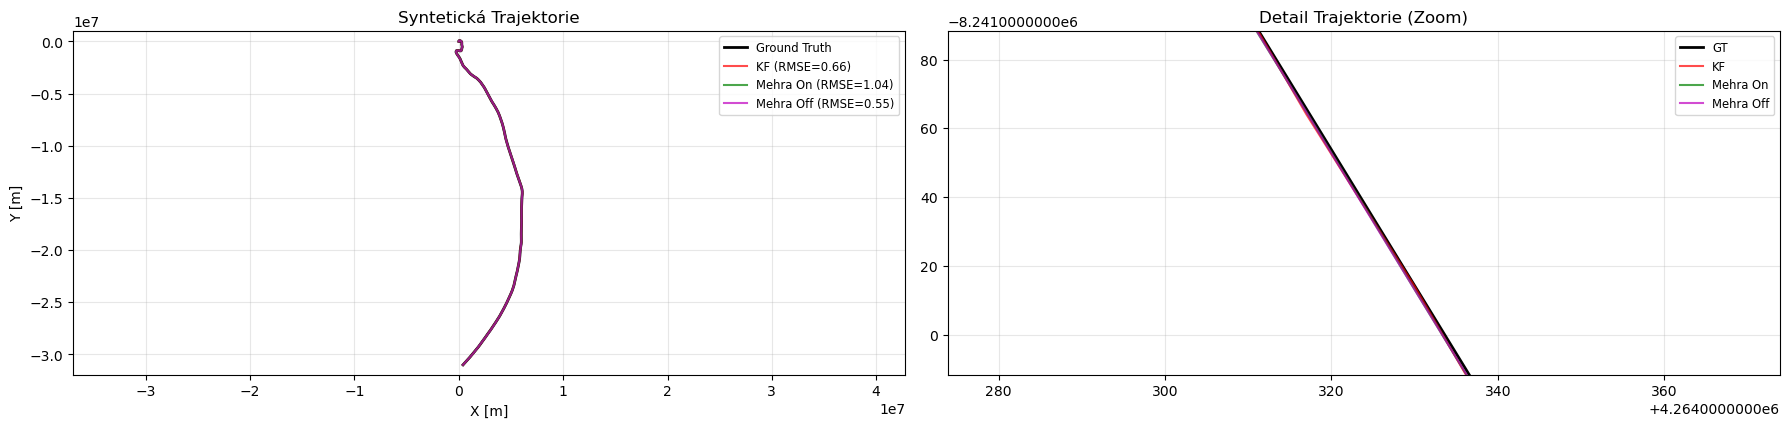


Generuji detailní grafy vývoje Kalmanovy matice K...


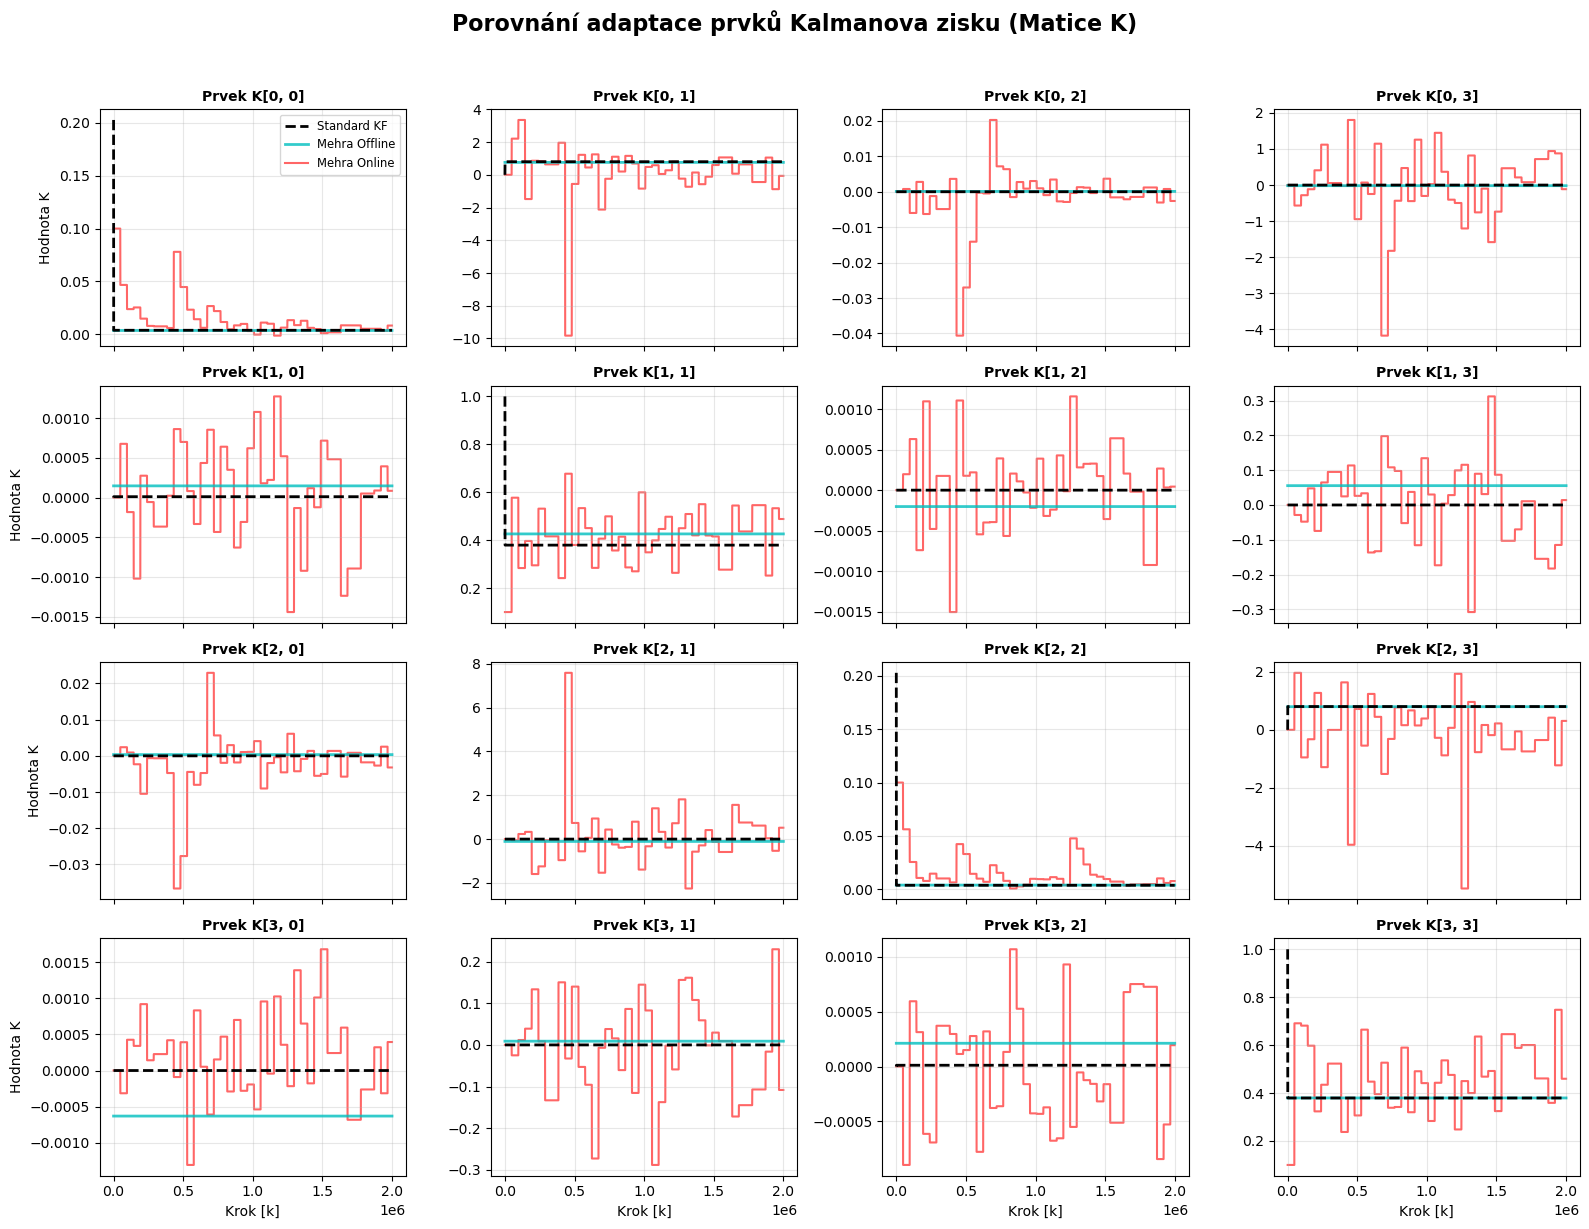

In [11]:

# ==============================================================================
# 2. SPUŠTĚNÍ FILTRŮ
# ==============================================================================

# device = torch.device("cpu")
# --- C) STANDARDNÍ KF RUN (Běží v 64bit Double) ---
print("\nSpouštím standardní KF na syntetických datech...")
kf_filter = Filters.KalmanFilter(sys_true)
res_kf = kf_filter.process_sequence(y_seq, Ex0=sys_true.Ex0, P0=sys_true.P0)
print("KF dokončen.")


# alpha_nominal = [0.000132, 39.32, 0.00057]
# akf_filter = AdaptiveKalmanFilter_online(
#     sys_model, 
#     mdm_L=5, 
#     mdm_version=1,
#     lambda_rls=1,
#     init_sigma_rls_value=0.01,
#     alpha_nom=alpha_nominal
# )

# res_akf,_,_ = akf_filter.process_sequence_adaptively(y_seq, Ex0=sys_true.Ex0, P0=sys_true.P0)
# print("AKF dokončen.")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nSpouštím AKF Mehra (Online) na syntetických datech...")
akf_mehra_online = AdaptiveKalmanFilter_mehra(sys_true, window_size=48000)
res_akf_mehra = akf_mehra_online.process_sequence(y_seq, Ex0=sys_true.Ex0, P0=sys_true.P0)
print("AKF Mehra (Online) dokončen.")

print("\nSpouštím AKF Mehra (Offline) na syntetických datech...")
akf_mehra_offline = Filters.AdaptiveKalmanFilter_mehra_offline(sys_true, num_iterations=12)
res_akf_mehra_offline = akf_mehra_offline.process_sequence(y_seq, Ex0=sys_true.Ex0, P0=sys_true.P0)
print("AKF Mehra (Offline) dokončen.")


# ==============================================================================
# 3. VYHODNOCENÍ METRIK
# ==============================================================================
x_gt_np = x_gt.detach().cpu().numpy()
y_meas_np = y_seq.detach().cpu().numpy()

x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_mehra_on = res_akf_mehra['x_filtered'].detach().cpu().numpy()
x_est_mehra_off = res_akf_mehra_offline['x_filtered'].detach().cpu().numpy()
# x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
def calc_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    rmse = np.sqrt(total_mse)
    return total_mse, rmse

mse_kf, rmse_kf = calc_metrics(x_est_kf, x_gt_np)
mse_mehra_on, rmse_mehra_on = calc_metrics(x_est_mehra_on, x_gt_np)
mse_mehra_off, rmse_mehra_off = calc_metrics(x_est_mehra_off, x_gt_np)
# mse_akf, rmse_akf = calc_metrics(x_est_akf, x_gt_np)

print("\n" + "="*60)
print(f"VÝSLEDKY NA SYNTETICKÝCH DATECH:")
print(f"Standardní KF     -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF Mehra Online  -> MSE: {mse_mehra_on:.4f} | RMSE: {rmse_mehra_on:.4f} m")
# print(f"AKF               -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")
print(f"AKF Mehra Offline -> MSE: {mse_mehra_off:.4f} | RMSE: {rmse_mehra_off:.4f} m")
print("="*60)


# ==============================================================================
# 5. VYKRESLENÍ GRAFŮ (TRAJEKTORIE A ŠUMY)
# ==============================================================================
plt.figure(figsize=(18, 12))

# 1. Trajektorie X-Y
plt.subplot(3, 2, 1)
plt.plot(x_gt_np[:, 0], x_gt_np[:, 2], 'k-', linewidth=2, label='Ground Truth')
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', linewidth=1.5, alpha=0.7, label=f'KF (RMSE={rmse_kf:.2f})')
plt.plot(x_est_mehra_on[:, 0], x_est_mehra_on[:, 2], 'g-', linewidth=1.5, alpha=0.7, label=f'Mehra On (RMSE={rmse_mehra_on:.2f})')
plt.plot(x_est_mehra_off[:, 0], x_est_mehra_off[:, 2], 'm-', linewidth=1.5, alpha=0.7, label=f'Mehra Off (RMSE={rmse_mehra_off:.2f})')
# plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', linewidth=1.5, alpha=0.7, label=f'AKF (RMSE={rmse_akf:.2f})')
plt.title("Syntetická Trajektorie")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)
plt.axis('equal')

# 2. Detail Trajektorie
plt.subplot(3, 2, 2)
mid = len(x_gt_np)//2
span = 50
plt.plot(x_gt_np[:, 0], x_gt_np[:, 2], 'k-', linewidth=2, label='GT')
plt.plot(x_est_kf[:, 0], x_est_kf[:, 2], 'r-', alpha=0.7, label='KF')
plt.plot(x_est_mehra_on[:, 0], x_est_mehra_on[:, 2], 'g-', alpha=0.7, label='Mehra On')
plt.plot(x_est_mehra_off[:, 0], x_est_mehra_off[:, 2], 'm-', alpha=0.7, label='Mehra Off')
# plt.plot(x_est_akf[:, 0], x_est_akf[:, 2], 'b-', alpha=0.7, label='AKF')
plt.xlim(x_gt_np[mid, 0]-span, x_gt_np[mid, 0]+span)
plt.ylim(x_gt_np[mid, 2]-span, x_gt_np[mid, 2]+span)
plt.title("Detail Trajektorie (Zoom)")
plt.legend(fontsize='small')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ==============================================================================
# 6. VIZUALIZACE VÝVOJE KALMANOVA ZISKU (MATICE K)
# ==============================================================================
print("\nGeneruji detailní grafy vývoje Kalmanovy matice K...")

K_kf = res_kf['Kalman_gain'].detach().cpu().numpy()
K_mehra_on = res_akf_mehra['Kalman_gain'].detach().cpu().numpy()
K_mehra_off = res_akf_mehra_offline['Kalman_gain'].detach().cpu().numpy()
# K_akf = res_akf['Kalman_gain'].detach().cpu().numpy()

seq_len_K = K_kf.shape[0]
nx = K_kf.shape[1]
nz = K_kf.shape[2]
t_full = np.arange(seq_len_K)

fig_K, axes_K = plt.subplots(nx, nz, figsize=(4 * nz, 3 * nx), sharex=True)

if nx == 1 and nz == 1:
    axes_K = np.array([[axes_K]])
elif nx == 1:
    axes_K = axes_K[np.newaxis, :]
elif nz == 1:
    axes_K = axes_K[:, np.newaxis]

for i in range(nx):
    for j in range(nz):
        ax = axes_K[i, j]
        
        ax.plot(t_full, K_kf[:, i, j], 'k--', label='Standard KF', linewidth=2, zorder=4)
        ax.plot(t_full, K_mehra_off[:, i, j], 'c-', label='Mehra Offline', linewidth=2, alpha=0.8, zorder=3)
        ax.plot(t_full, K_mehra_on[:, i, j], 'r-', label='Mehra Online', linewidth=1.5, alpha=0.6, zorder=1)
        # ax.plot(t_full, K_akf[:, i, j], 'b-', label='AKF', linewidth=1.5, alpha=0.6, zorder=2)

        ax.set_title(f'Prvek K[{i}, {j}]', fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        if j == 0:
            ax.set_ylabel('Hodnota K')
        if i == nx - 1:
            ax.set_xlabel('Krok [k]')
        if i == 0 and j == 0:
            ax.legend(loc='best', fontsize='small')

plt.suptitle('Porovnání adaptace prvků Kalmanova zisku (Matice K)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ADAPTIVE AKF MDM

Běžím na zařízení: cpu



VÝSLEDKY NA SYNTETICKÝCH DATECH (Pouze pozice X, Y):
Standardní KF (Špatný start) -> MSE: 0.3136 | RMSE: 0.5600 m
AKF Mehra Online             -> MSE: 2.4032 | RMSE: 1.5502 m
AKF MDM (Adaptivní)          -> MSE: 0.3135 | RMSE: 0.5599 m

KONTROLA KONVERGENCE MDM ALGORITMU K 'TRUE' HODNOTÁM:
1. Šum procesu (q_scale):
   Skutečná (Cílová):  0.000132
   Odhad MDM (Konec):  0.000131
----------------------------------------------------------------------
2. Šum GPS (var_gps):
   Skutečná (Cílová):  39.321669
   Odhad MDM (Konec):  37.980691
----------------------------------------------------------------------
3. Šum Odometrie (var_odo):
   Skutečná (Cílová):  0.000570
   Odhad MDM (Konec):  0.000570


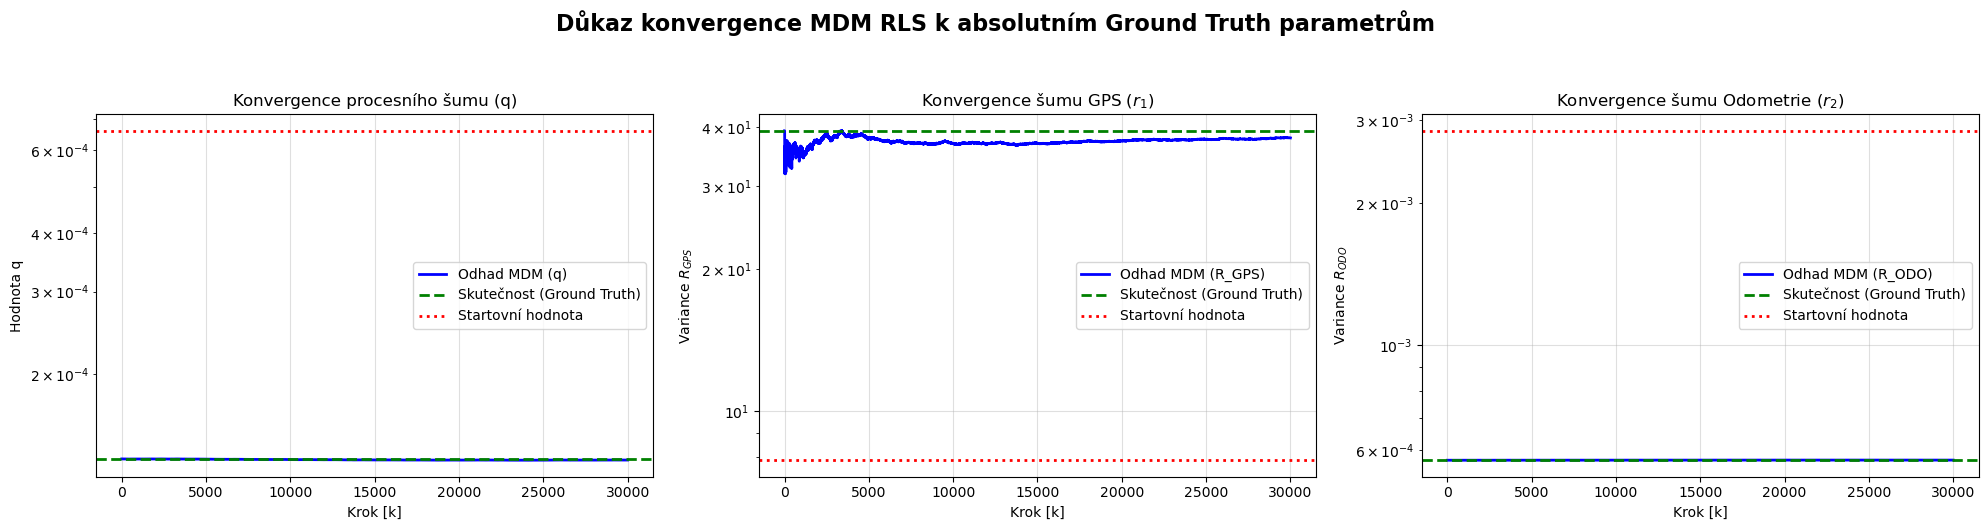

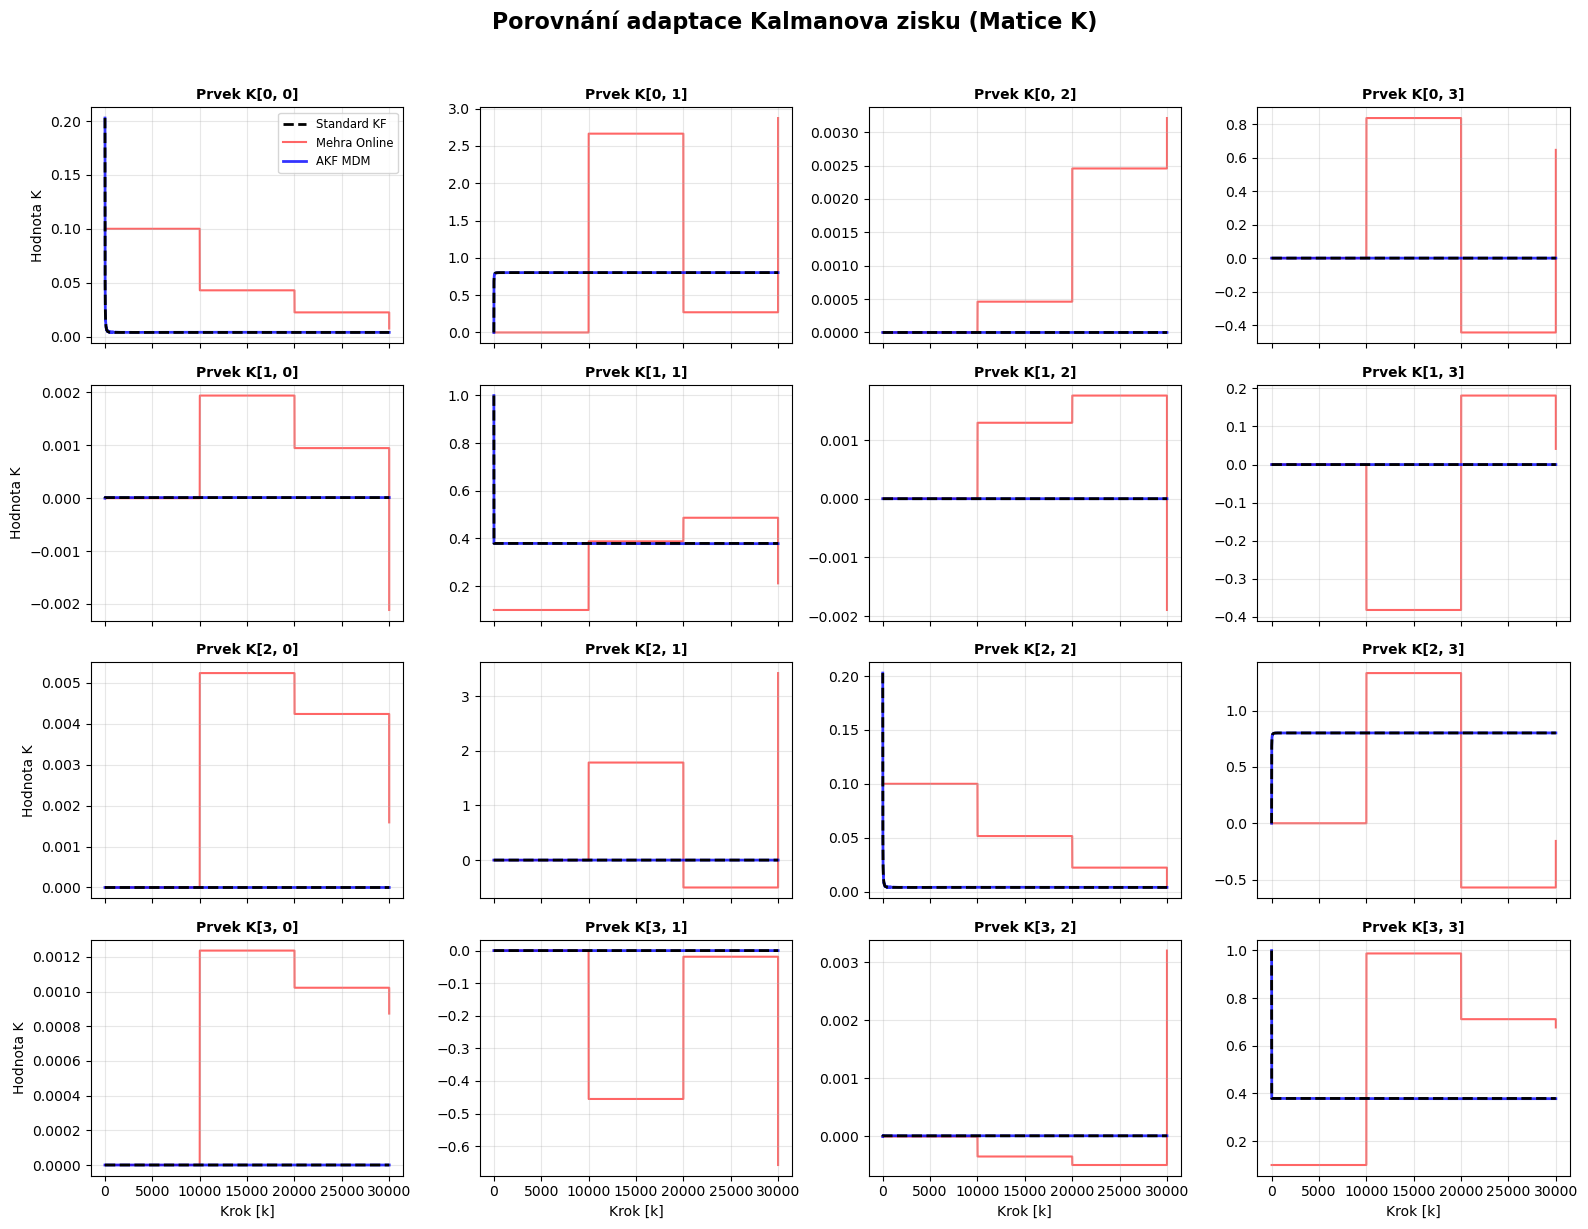

In [ ]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
import Systems
import Filters
from tqdm import tqdm

# Vynutíme CPU pro syntetický test
device = torch.device("cpu")
print(f"Běžím na zařízení: {device}")

#########################
### Design Parameters ###
#########################
m = 4 
n = 4 
delta_t = 1.0 

F_dim = torch.tensor([[1.0, delta_t], [0.0, 1.0]], dtype=torch.float64)
F_design = torch.block_diag(F_dim, F_dim).to(device)
H_design = torch.eye(n, dtype=torch.float64).to(device)

# ==============================================================================
# 1. SKUTEČNÉ PARAMETRY (Těmito daty generujeme trajektorii)
# ==============================================================================
q_true = 0.00013203
var_gps_true = 39.321669
var_odo_true = 0.00057

Q_block_true = torch.tensor([[(delta_t**3)/3, (delta_t**2)/2], [(delta_t**2)/2, delta_t]], dtype=torch.float64) * q_true
Q_true = torch.block_diag(Q_block_true, Q_block_true).to(device)

R_true = torch.tensor([
    [var_gps_true, 0.0, 0.0, 0.0],
    [0.0, var_odo_true, 0.0, 0.0],
    [0.0, 0.0, var_gps_true, 0.0],
    [0.0, 0.0, 0.0, var_odo_true]
], dtype=torch.float64).to(device)

m1x_0_generic = torch.zeros(m, 1, dtype=torch.float64).to(device)
m2x_0 = torch.diag(torch.tensor([10.0, 1.0, 10.0, 1.0], dtype=torch.float64)).to(device)

sys_true = Systems.DynamicSystem(
    state_dim=m, obs_dim=n, Ex0=m1x_0_generic, P0=m2x_0,
    Q=Q_true, R=R_true, F=F_design, H=H_design, device=device
)

# ==============================================================================
# 2. STARTOVNÍ (CHYBNÉ) PARAMETRY PRO FILTRY (Pro test konvergence)
# ==============================================================================
# Úmyslně dáme filtru špatný nástřel, aby měl MDM co opravovat
q_start = q_true * 5.0             # 5x větší šum modelu
var_gps_start = var_gps_true / 5.0 # 5x menší šum GPS (přehnaná důvěra)
var_odo_start = var_odo_true * 5.0 # 5x větší šum odometrie

alpha_true = [q_true, var_gps_true, var_odo_true]
alpha_start = [q_start, var_gps_start, var_odo_start]


# ==============================================================================
# 3. GENEROVÁNÍ SYNTETICKÝCH DAT
# ==============================================================================
def generate_linear_data(sys, length=20000):
    x_true = torch.zeros(length, sys.state_dim, dtype=torch.float64).to(device)
    y_meas = torch.zeros(length, sys.obs_dim, dtype=torch.float64).to(device)

    dist_Q = torch.distributions.MultivariateNormal(torch.zeros(sys.state_dim, dtype=torch.float64).to(device), sys.Q)
    dist_R = torch.distributions.MultivariateNormal(torch.zeros(sys.obs_dim, dtype=torch.float64).to(device), sys.R)
    
    noise_Q_all = dist_Q.sample((length,))
    noise_R_all = dist_R.sample((length,))
    
    x_curr = torch.distributions.MultivariateNormal(sys.Ex0.flatten(), sys.P0).sample()
    
    for t in tqdm(range(length), desc="Generování syntetických dat", leave=False):
        x_true[t] = x_curr
        y_meas[t] = (sys.H @ x_curr) + noise_R_all[t]
        x_curr = (sys.F @ x_curr) + noise_Q_all[t]
        
    return x_true, y_meas

seq_length = 30000
x_gt, y_seq = generate_linear_data(sys_true, length=seq_length)

# ZÍSKÁNÍ PŘESNÉHO POČÁTEČNÍHO STAVU (Zabrání úvodnímu šoku filtru)
exact_x0 = x_gt[0].unsqueeze(1).clone()

kf_filter = Filters.KalmanFilter(sys_true)
res_kf = kf_filter.process_sequence(y_seq, Ex0=exact_x0, P0=sys_model.P0)

alpha_nominal = [0.000132, 39.32, 0.00057]

akf_filter = AdaptiveKalmanFilter_online(
    sys_true, 
    mdm_L=6, 
    mdm_version=1, 
    lambda_rls=1.0, 
    init_sigma_rls_value=0.01, 
    alpha_nom=alpha_nominal
)
res_akf, Q_hist, R_hist = akf_filter.process_sequence_adaptively(y_seq, Ex0=exact_x0, P0=sys_model.P0)

akf_mehra_online = Filters.AdaptiveKalmanFilter_mehra(sys_true, window_size=10000)
res_akf_mehra = akf_mehra_online.process_sequence(y_seq, Ex0=exact_x0, P0=sys_model.P0)

# ==============================================================================
# 5. VÝPOČET METRIK (Čistě pozice X a Y)
# ==============================================================================
x_gt_np = x_gt.detach().cpu().numpy()
x_est_kf = res_kf['x_filtered'].detach().cpu().numpy()
x_est_akf = res_akf['x_filtered'].detach().cpu().numpy()
x_est_mehra = res_akf_mehra['x_filtered'].detach().cpu().numpy()

def calc_pos_metrics(est, gt):
    mse_x = np.mean((est[:, 0] - gt[:, 0])**2)
    mse_y = np.mean((est[:, 2] - gt[:, 2])**2)
    total_mse = mse_x + mse_y
    return total_mse, np.sqrt(total_mse)

mse_kf, rmse_kf = calc_pos_metrics(x_est_kf, x_gt_np)
mse_akf, rmse_akf = calc_pos_metrics(x_est_akf, x_gt_np)
mse_mehra, rmse_mehra = calc_pos_metrics(x_est_mehra, x_gt_np)

# ==============================================================================
# 6. EXTRAKCE HODNOT A VÝPIS DO KONZOLE
# ==============================================================================
template_val_00 = (delta_t**3) / 3.0

q_est_values = np.array([q[0, 0].item() for q in Q_hist]) / template_val_00
r_gps_hist = np.array([r[0, 0].item() for r in R_hist]) 
r_odo_hist = np.array([r[1, 1].item() for r in R_hist]) 

print("\n" + "="*70)
print("VÝSLEDKY NA SYNTETICKÝCH DATECH (Pouze pozice X, Y):")
print("="*70)
print(f"Standardní KF -> MSE: {mse_kf:.4f} | RMSE: {rmse_kf:.4f} m")
print(f"AKF Mehra Online             -> MSE: {mse_mehra:.4f} | RMSE: {rmse_mehra:.4f} m")
print(f"AKF MDM (Adaptivní)          -> MSE: {mse_akf:.4f} | RMSE: {rmse_akf:.4f} m")

print("\n" + "="*70)
print("KONTROLA KONVERGENCE MDM ALGORITMU K 'TRUE' HODNOTÁM:")
print("="*70)
print(f"1. Šum procesu (q_scale):")
print(f"   Skutečná (Cílová):  {q_true:.6f}")
print(f"   Odhad MDM (Konec):  {q_est_values[-1]:.6f}")
print("-" * 70)
print(f"2. Šum GPS (var_gps):")
print(f"   Skutečná (Cílová):  {var_gps_true:.6f}")
print(f"   Odhad MDM (Konec):  {r_gps_hist[-1]:.6f}")
print("-" * 70)
print(f"3. Šum Odometrie (var_odo):")
print(f"   Skutečná (Cílová):  {var_odo_true:.6f}")
print(f"   Odhad MDM (Konec):  {r_odo_hist[-1]:.6f}")
print("="*70)

# ==============================================================================
# 7. VYKRESLENÍ GRAFŮ (KONVERGENCE PARAMETRŮ Q A R)
# ==============================================================================
t_akf = np.arange(len(q_est_values))
fig_params, axes = plt.subplots(1, 3, figsize=(20, 5))
fig_params.suptitle("Důkaz konvergence MDM RLS k absolutním Ground Truth parametrům", fontsize=16, fontweight='bold', y=1.05)

# Graf q
axes[0].plot(t_akf, q_est_values, 'b-', linewidth=2, label='Odhad MDM (q)')
axes[0].axhline(q_true, color='g', linestyle='--', linewidth=2, label='Skutečnost (Ground Truth)')
axes[0].axhline(q_start, color='r', linestyle=':', linewidth=2, label='Startovní hodnota')
axes[0].set_title('Konvergence procesního šumu (q)')
axes[0].set_ylabel('Hodnota q')
axes[0].set_xlabel('Krok [k]')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Graf R_GPS
axes[1].plot(t_akf, r_gps_hist, 'b-', linewidth=2, label='Odhad MDM (R_GPS)')
axes[1].axhline(var_gps_true, color='g', linestyle='--', linewidth=2, label='Skutečnost (Ground Truth)')
axes[1].axhline(var_gps_start, color='r', linestyle=':', linewidth=2, label='Startovní hodnota')
axes[1].set_title('Konvergence šumu GPS ($r_1$)')
axes[1].set_ylabel('Variance $R_{GPS}$')
axes[1].set_xlabel('Krok [k]')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Graf R_ODO
axes[2].plot(t_akf, r_odo_hist, 'b-', linewidth=2, label='Odhad MDM (R_ODO)')
axes[2].axhline(var_odo_true, color='g', linestyle='--', linewidth=2, label='Skutečnost (Ground Truth)')
axes[2].axhline(var_odo_start, color='r', linestyle=':', linewidth=2, label='Startovní hodnota')
axes[2].set_title('Konvergence šumu Odometrie ($r_2$)')
axes[2].set_ylabel('Variance $R_{ODO}$')
axes[2].set_xlabel('Krok [k]')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ==============================================================================
# 8. VYKRESLENÍ VÝVOJE KALMANOVA ZISKU K (Porovnání s Mehrou)
# ==============================================================================
K_kf = res_kf['Kalman_gain'].detach().cpu().numpy()
K_mehra_on = res_akf_mehra['Kalman_gain'].detach().cpu().numpy()
K_akf = res_akf['Kalman_gain'].detach().cpu().numpy()

nx, nz = K_kf.shape[1], K_kf.shape[2]
t_full = np.arange(K_kf.shape[0])

fig_K, axes_K = plt.subplots(nx, nz, figsize=(4 * nz, 3 * nx), sharex=True)
if nx == 1 and nz == 1: axes_K = np.array([[axes_K]])
elif nx == 1: axes_K = axes_K[np.newaxis, :]
elif nz == 1: axes_K = axes_K[:, np.newaxis]

for i in range(nx):
    for j in range(nz):
        ax = axes_K[i, j]
        ax.plot(t_full, K_kf[:, i, j], 'k--', label='Standard KF', linewidth=2, zorder=4)
        ax.plot(t_full, K_mehra_on[:, i, j], 'r-', label='Mehra Online', linewidth=1.5, alpha=0.6, zorder=1)
        ax.plot(t_full, K_akf[:, i, j], 'b-', label='AKF MDM', linewidth=2, alpha=0.8, zorder=2)
        ax.set_title(f'Prvek K[{i}, {j}]', fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.3)
        if j == 0: ax.set_ylabel('Hodnota K')
        if i == nx - 1: ax.set_xlabel('Krok [k]')
        if i == 0 and j == 0: ax.legend(loc='best', fontsize='small')

plt.suptitle('Porovnání adaptace Kalmanova zisku (Matice K)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()